In [3]:
pip install pandas numpy matplotlib seaborn pathlib


   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   -------------------- ------------------- 1/2 [seaborn]
   ---------------------------------------- 2/2 [seaborn]

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

DATA = Path("data")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [5]:
homes    = pd.read_csv(DATA / "homes.csv")
residents = pd.read_csv(DATA / "residents.csv", parse_dates=["admission_date", "discharge_date", "dob"])
census   = pd.read_csv(DATA / "daily_census.csv", parse_dates=["date"])
staffing = pd.read_csv(DATA / "staffing.csv", parse_dates=["date"])

print(f"homes: {homes.shape}, residents: {residents.shape}, census: {census.shape}, staffing: {staffing.shape}")

homes: (50, 3), residents: (2809, 8), census: (18250, 6), staffing: (54750, 6)


In [6]:
# Aggregate staffing to daily level first (sum across shifts)
daily_staff = (
    staffing.groupby(["home_id", "date"])
    .agg(
        staff_hours=("staff_hours", "sum"),
        required_hours=("required_hours", "sum"),
        staff_cost=("staff_cost", "sum"),
    )
    .reset_index()
)
daily_staff["efficiency_ratio"] = daily_staff["staff_hours"] / daily_staff["required_hours"]

# Merge census with daily staffing
daily = census.merge(daily_staff, on=["home_id", "date"])

# Home-level aggregation
summary = (
    daily.groupby("home_id")
    .agg(
        avg_occupancy_rate=("occupancy_rate", "mean"),
        avg_dependency=("avg_dependency", "mean"),
        avg_efficiency_ratio=("efficiency_ratio", "mean"),
        total_staff_cost=("staff_cost", "sum"),
        total_occupied_beds=("occupied_beds", "sum"),
    )
    .reset_index()
)
summary["cost_per_occupied_bed"] = summary["total_staff_cost"] / summary["total_occupied_beds"]
summary = summary.merge(homes[["home_id", "bed_capacity"]], on="home_id")

summary.head()

,home_id,avg_occupancy_rate,avg_dependency,avg_efficiency_ratio,total_staff_cost,total_occupied_beds,cost_per_occupied_bed,bed_capacity
0,h001,0.903914,3.836495,1.003619,1738311.12,23095,75.267855,70
1,h002,0.879726,3.727057,0.998292,721138.61,9633,74.861270,30
2,h003,0.856644,3.688563,0.999723,937847.22,12507,74.985786,40
3,h004,0.850137,4.090283,0.999432,930138.81,12412,74.938673,40
4,h005,0.917397,3.797984,0.995764,1000305.25,13394,74.683086,40


In [7]:
def flag_home(row, occ_lo, occ_hi, dep_lo, dep_hi, eff_lo, eff_hi, cost_hi):
    high_occ = row["avg_occupancy_rate"] > occ_hi
    low_occ  = row["avg_occupancy_rate"] < occ_lo
    high_dep = row["avg_dependency"] > dep_hi
    low_dep  = row["avg_dependency"] < dep_lo
    low_eff  = row["avg_efficiency_ratio"] < eff_lo
    high_eff = row["avg_efficiency_ratio"] > eff_hi
    high_cost = row["cost_per_occupied_bed"] > cost_hi

    if high_dep and high_occ and low_eff:
        return "understaffed"
    elif low_dep and low_occ and high_eff:
        return "overstaffed"
    elif high_cost and low_occ:
        return "inefficient"
    else:
        return "well-calibrated"

# Percentile-based thresholds (33rd / 67th)
thresholds = {
    "occ_lo":   summary["avg_occupancy_rate"].quantile(0.33),
    "occ_hi":   summary["avg_occupancy_rate"].quantile(0.67),
    "dep_lo":   summary["avg_dependency"].quantile(0.33),
    "dep_hi":   summary["avg_dependency"].quantile(0.67),
    "eff_lo":   summary["avg_efficiency_ratio"].quantile(0.33),
    "eff_hi":   summary["avg_efficiency_ratio"].quantile(0.67),
    "cost_hi":  summary["cost_per_occupied_bed"].quantile(0.67),
}

summary["flag"] = summary.apply(flag_home, axis=1, **thresholds)
summary["flag"].value_counts()

flag
well-calibrated    42
inefficient         4
overstaffed         3
understaffed        1
Name: count, dtype: int64

In [8]:
def flag_home(row, occ_lo, occ_hi, dep_lo, dep_hi, eff_lo, eff_hi, cost_hi):
    high_occ = row["avg_occupancy_rate"] > occ_hi
    low_occ  = row["avg_occupancy_rate"] < occ_lo
    high_dep = row["avg_dependency"] > dep_hi
    low_dep  = row["avg_dependency"] < dep_lo
    low_eff  = row["avg_efficiency_ratio"] < eff_lo
    high_eff = row["avg_efficiency_ratio"] > eff_hi
    high_cost = row["cost_per_occupied_bed"] > cost_hi

    if high_dep and high_occ and low_eff:
        return "understaffed"
    elif low_dep and low_occ and high_eff:
        return "overstaffed"
    elif high_cost and low_occ:
        return "inefficient"
    else:
        return "well-calibrated"

# Percentile-based thresholds (33rd / 67th)
thresholds = {
    "occ_lo":   summary["avg_occupancy_rate"].quantile(0.33),
    "occ_hi":   summary["avg_occupancy_rate"].quantile(0.67),
    "dep_lo":   summary["avg_dependency"].quantile(0.33),
    "dep_hi":   summary["avg_dependency"].quantile(0.67),
    "eff_lo":   summary["avg_efficiency_ratio"].quantile(0.33),
    "eff_hi":   summary["avg_efficiency_ratio"].quantile(0.67),
    "cost_hi":  summary["cost_per_occupied_bed"].quantile(0.67),
}

summary["flag"] = summary.apply(flag_home, axis=1, **thresholds)
summary["flag"].value_counts()

flag
well-calibrated    42
inefficient         4
overstaffed         3
understaffed        1
Name: count, dtype: int64

In [9]:
FLAG_COLORS = {
    "understaffed":    "#E24B4A",
    "overstaffed":     "#EF9F27",
    "inefficient":     "#D4537E",
    "well-calibrated": "#1D9E75",
}

In [10]:
Path("outputs").mkdir(exist_ok=True)

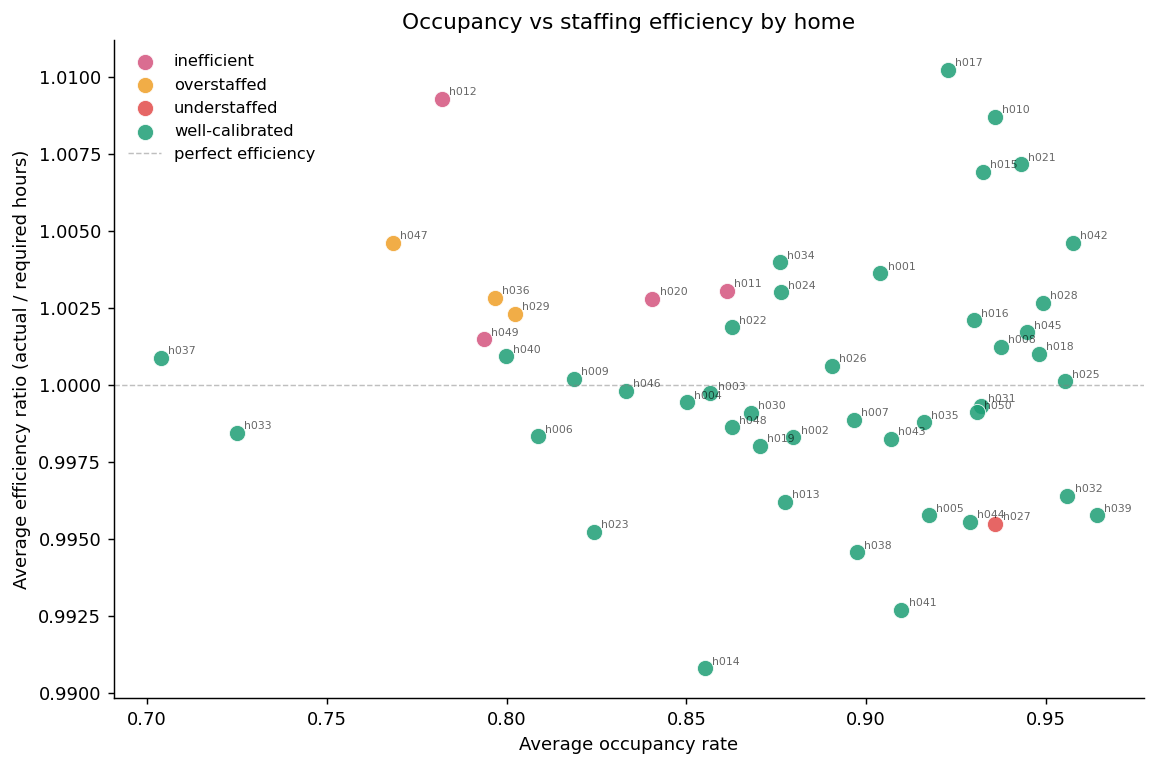

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

for flag, grp in summary.groupby("flag"):
    ax.scatter(
        grp["avg_occupancy_rate"],
        grp["avg_efficiency_ratio"],
        label=flag,
        color=FLAG_COLORS[flag],
        alpha=0.85, s=80, edgecolors="white", linewidths=0.5,
    )
    for _, row in grp.iterrows():
        ax.annotate(row["home_id"], (row["avg_occupancy_rate"], row["avg_efficiency_ratio"]),
                    fontsize=6, alpha=0.6, xytext=(4, 2), textcoords="offset points")

ax.axhline(1.0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5, label="perfect efficiency")
ax.set_xlabel("Average occupancy rate")
ax.set_ylabel("Average efficiency ratio (actual / required hours)")
ax.set_title("Occupancy vs staffing efficiency by home")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("outputs/scatter_occ_vs_eff.png", dpi=150)
plt.show()

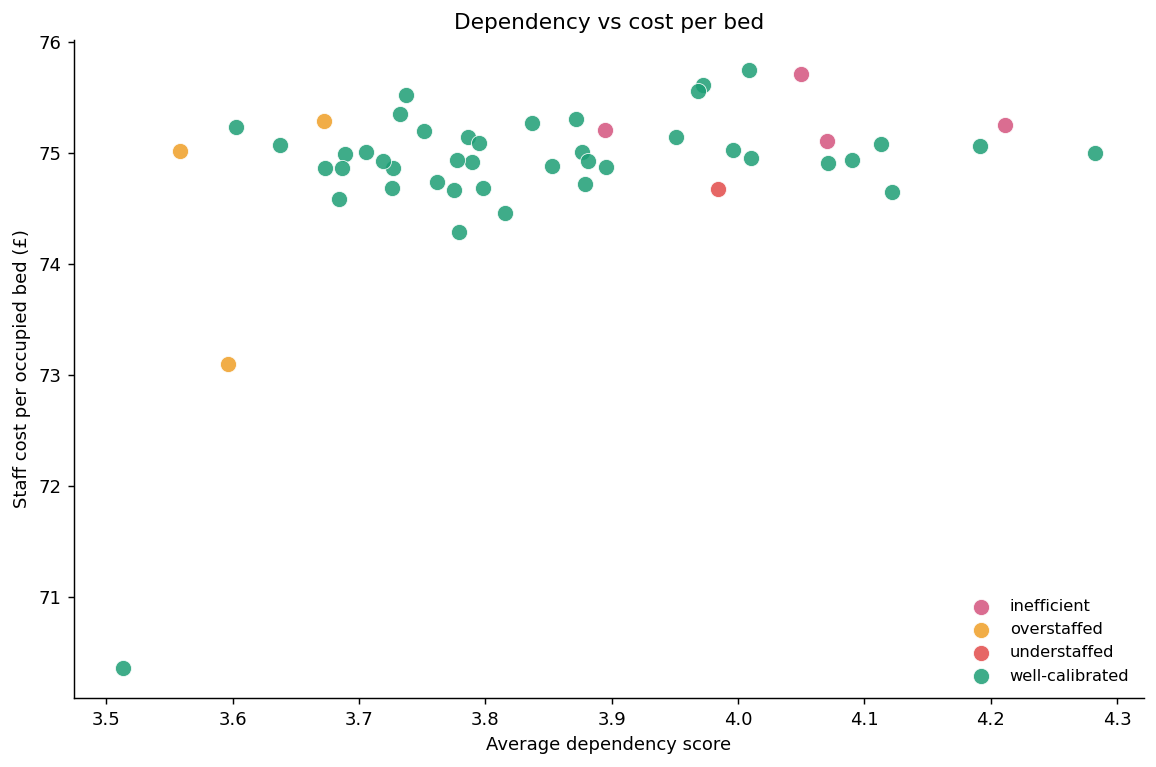

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

for flag, grp in summary.groupby("flag"):
    ax.scatter(
        grp["avg_dependency"],
        grp["cost_per_occupied_bed"],
        label=flag,
        color=FLAG_COLORS[flag],
        alpha=0.85, s=80, edgecolors="white", linewidths=0.5,
    )

ax.set_xlabel("Average dependency score")
ax.set_ylabel("Staff cost per occupied bed (£)")
ax.set_title("Dependency vs cost per bed")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("outputs/scatter_dep_vs_cost.png", dpi=150)
plt.show()

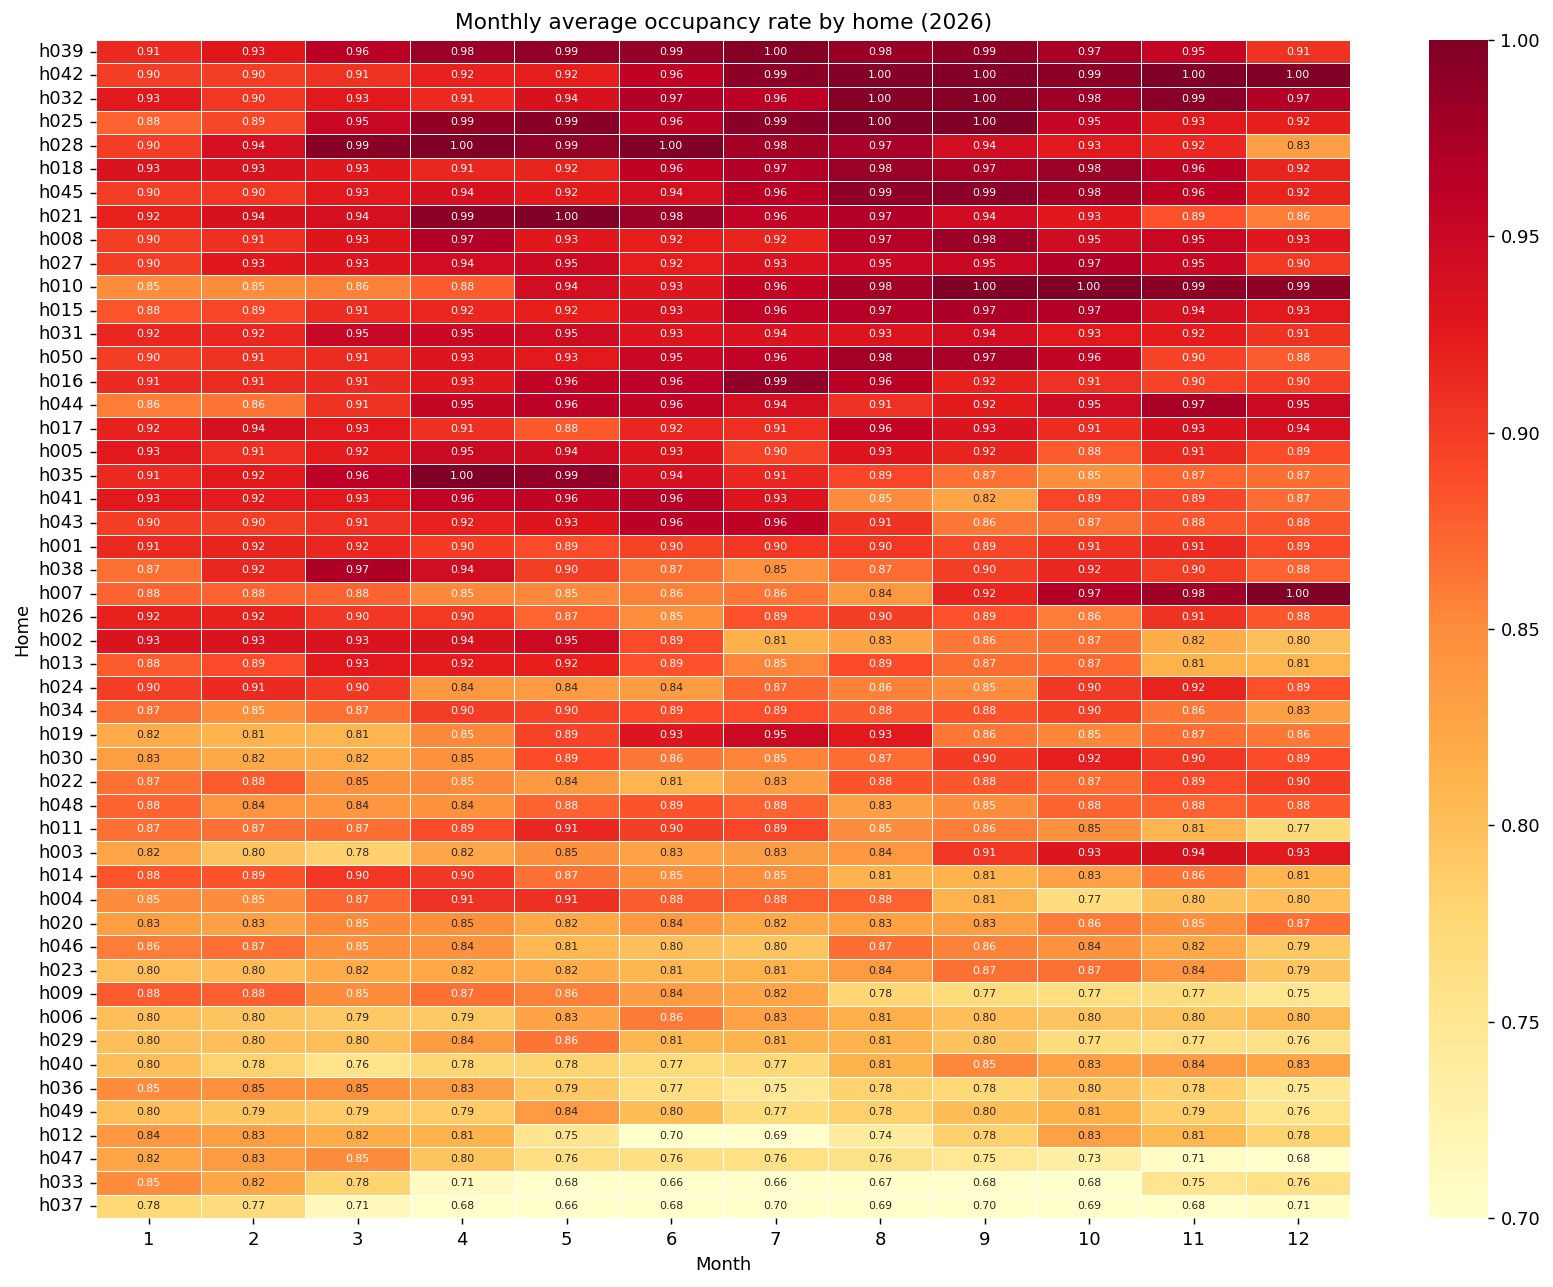

In [13]:
census["month"] = census["date"].dt.month
monthly_occ = (
    census.groupby(["home_id", "month"])["occupancy_rate"]
    .mean()
    .unstack("month")
)
# Sort homes by avg occupancy descending
monthly_occ = monthly_occ.loc[monthly_occ.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    monthly_occ,
    cmap="YlOrRd",
    vmin=0.7, vmax=1.0,
    linewidths=0.3, linecolor="white",
    annot=True, fmt=".2f", annot_kws={"size": 6},
    ax=ax,
)
ax.set_title("Monthly average occupancy rate by home (2026)")
ax.set_xlabel("Month")
ax.set_ylabel("Home")
plt.tight_layout()
plt.savefig("outputs/heatmap_occupancy.png", dpi=150)
plt.show()

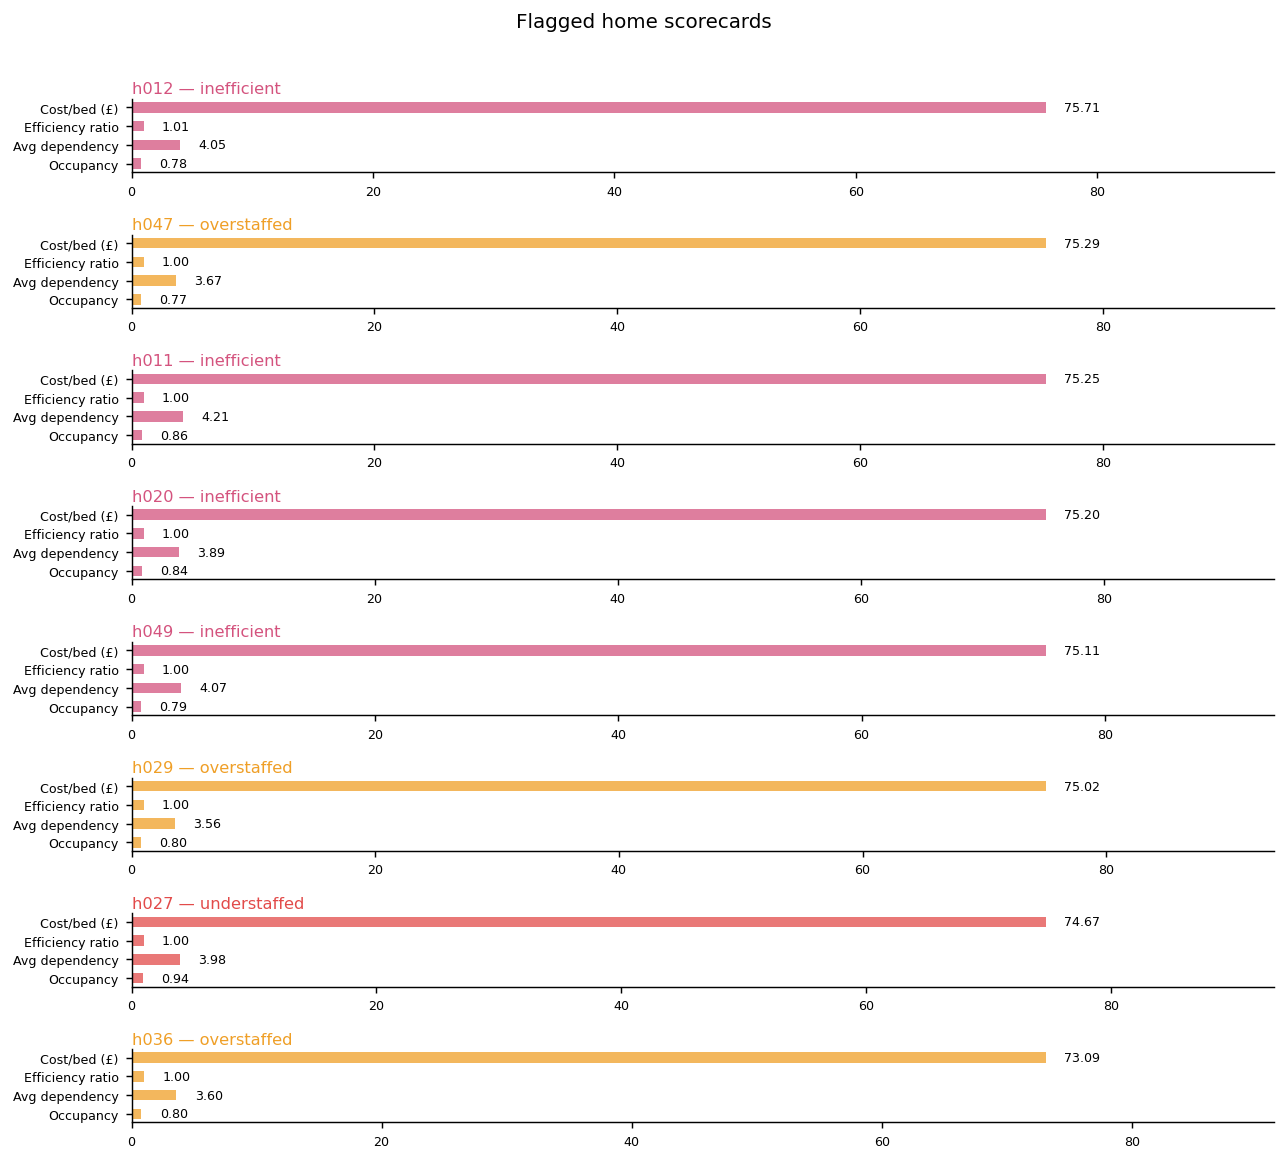

In [14]:
flagged = summary[summary["flag"] != "well-calibrated"].sort_values("cost_per_occupied_bed", ascending=False)

fig, axes = plt.subplots(len(flagged), 1, figsize=(10, len(flagged) * 1.1))
if len(flagged) == 1:
    axes = [axes]

metrics = ["avg_occupancy_rate", "avg_dependency", "avg_efficiency_ratio", "cost_per_occupied_bed"]
labels  = ["Occupancy", "Avg dependency", "Efficiency ratio", "Cost/bed (£)"]

for ax, (_, row) in zip(axes, flagged.iterrows()):
    color = FLAG_COLORS[row["flag"]]
    values = [row[m] for m in metrics]
    bars = ax.barh(labels, values, color=color, alpha=0.75, height=0.55)
    ax.set_xlim(0, max(values) * 1.25)
    ax.set_title(f"{row['home_id']} — {row['flag']}", fontsize=9, color=color, loc="left", pad=3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + max(values) * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Flagged home scorecards", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("outputs/scorecards.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
cols = ["home_id", "flag", "avg_occupancy_rate", "avg_dependency",
        "avg_efficiency_ratio", "cost_per_occupied_bed", "total_staff_cost"]

display(
    summary.sort_values("cost_per_occupied_bed", ascending=False)[cols]
    .style
    .background_gradient(subset=["avg_efficiency_ratio"], cmap="RdYlGn")
    .background_gradient(subset=["cost_per_occupied_bed"], cmap="YlOrRd")
    .format({
        "avg_occupancy_rate": "{:.1%}",
        "avg_dependency": "{:.2f}",
        "avg_efficiency_ratio": "{:.3f}",
        "cost_per_occupied_bed": "£{:.2f}",
        "total_staff_cost": "£{:,.0f}",
    })
)

,home_id,flag,avg_occupancy_rate,avg_dependency,avg_efficiency_ratio,cost_per_occupied_bed,total_staff_cost
16,h017,well-calibrated,92.3%,4.01,1.010,£75.75,"£1,275,699"
11,h012,inefficient,78.2%,4.05,1.009,£75.71,"£1,080,606"
9,h010,well-calibrated,93.6%,3.97,1.009,£75.62,"£1,035,862"
20,h021,well-calibrated,94.3%,3.97,1.007,£75.56,"£1,304,016"
14,h015,well-calibrated,93.2%,3.74,1.007,£75.52,"£1,542,224"
41,h042,well-calibrated,95.7%,3.73,1.005,£75.35,"£1,320,862"
33,h034,well-calibrated,87.6%,3.87,1.004,£75.30,"£1,444,464"
46,h047,overstaffed,76.8%,3.67,1.005,£75.29,"£844,703"
0,h001,well-calibrated,90.4%,3.84,1.004,£75.27,"£1,738,311"
10,h011,inefficient,86.1%,4.21,1.003,£75.25,"£1,419,428"
